<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overfitting in Machine Learning

**What is Overfitting?**

Imagine a student who memorises every question and answer from past exam papers.
They score 100% on those old papers — but when the real exam has slightly different questions, they fail.
They memorised the answers, they did not understand the concepts.

A machine learning model that **overfits** behaves the same way:
- It performs extremely well on training data
- It performs poorly on new, unseen data
- It memorised the training data instead of learning the pattern

**Why does it happen?**
The model is **too complex** for the data. It has too many parameters and starts fitting the noise along with the signal.

**In this notebook:**
1. Load the California Housing dataset
2. See overfitting happen — and understand why
3. Fix it step by step using two methods

## Step 1 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rich import print
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.

## Step 2 — Load the Dataset

We use the **California Housing dataset** — a real dataset from the 1990 US Census.

Each row is a housing district in California. The goal is to predict the **median house value**.

| Feature | Meaning |
|---|---|
| MedInc | Median income of the district |
| HouseAge | Median age of houses |
| AveRooms | Average number of rooms |
| AveBedrms | Average number of bedrooms |
| Population | District population |
| AveOccup | Average household occupancy |
| Latitude | Geographic latitude |
| Longitude | Geographic longitude |
| **HouseValue** | **Target — median house value ($100,000s)** |

In [ ]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['HouseValue'] = housing.target

print('Dataset shape:', df.shape)
print('\nSample rows:')
print(df.head())
print('\nBasic statistics:')
print(df.describe().round(2))

Dataset shape:
(20640, 9)

Sample rows:

MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HouseValue  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422

Basic statistics:

MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  HouseValue  
count  20640.00   20640.00    20640.00  
mean      35.63    -119.57        2.07  
std        2.14       2.00        1.15  
min       32.54    -124.35        0.15  
25%       33.93    -121.80        1.20  
50%       34.26    -118.49        1.80  
75%       37.71    -118.01        2.65  
max       41.95    -114.31        5.00

In [ ]:
X = df[housing.feature_names].values
y = df['HouseValue'].values

# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'\nThe model will learn from {len(X_train)} rows.')
print(f'We will test it on {len(X_test)} rows it has never seen.')

Training samples : 14448

Test samples     : 6192

The model will learn from 14448 rows.

We will test it on 6192 rows it has never seen.

## Step 3 — Create an Overfitting Model

We will use a **Decision Tree Regressor with no depth limit**.

A Decision Tree splits the data into smaller and smaller groups based on feature values.
With no depth limit, it keeps splitting until every single training sample is in its own group.

The result: the model perfectly memorises every training row.
Train error becomes 0 — but test error is high because the model learned noise, not pattern.

This is a classic, easy-to-demonstrate case of overfitting.

In [ ]:
# Overfit model: Decision Tree with no depth limit
model_of = DecisionTreeRegressor(max_depth=None, random_state=42)
model_of.fit(X_train, y_train)

train_pred_of = model_of.predict(X_train)
test_pred_of  = model_of.predict(X_test)

train_r2_of  = r2_score(y_train, train_pred_of)
test_r2_of   = r2_score(y_test,  test_pred_of)
train_mse_of = mean_squared_error(y_train, train_pred_of)
test_mse_of  = mean_squared_error(y_test,  test_pred_of)

print('OVERFIT MODEL — Decision Tree with no depth limit')
print('-' * 55)
print(f'  Training  R2  : {train_r2_of:.4f}  <- perfect score, memorised every row')
print(f'  Test      R2  : {test_r2_of:.4f}  <- much lower on unseen data')
print(f'  Training  MSE : {train_mse_of:.6f}')
print(f'  Test      MSE : {test_mse_of:.4f}')
print()
print(f'  Gap (Test R2 - Train R2) : {test_r2_of - train_r2_of:.4f}')
print()
print('Training R2 = 1.0 means perfect fit on training data.')
print('But the large drop in Test R2 tells us the model has overfit.')
print('It memorised the training data instead of learning a general pattern.')

OVERFIT MODEL — Decision Tree with no depth limit

-------------------------------------------------------

Training  R2  : 1.0000  <- perfect score, memorised every row

Test      R2  : 0.5977  <- much lower on unseen data

Training  MSE : 0.000000

Test      MSE : 0.5280

Gap (Test R2 - Train R2) : -0.4023

Training R2 = 1.0 means perfect fit on training data.

But the large drop in Test R2 tells us the model has overfit.

It memorised the training data instead of learning a general pattern.

### Visualise the Overfit Model

The **Actual vs Predicted** plot is the clearest way to see how a model is performing.

- Each dot is one test sample
- X-axis = actual house value
- Y-axis = what the model predicted
- The dashed diagonal line = perfect prediction

For a good model, dots cluster tightly along the diagonal.
For an overfit model, dots scatter widely — predictions are unreliable.

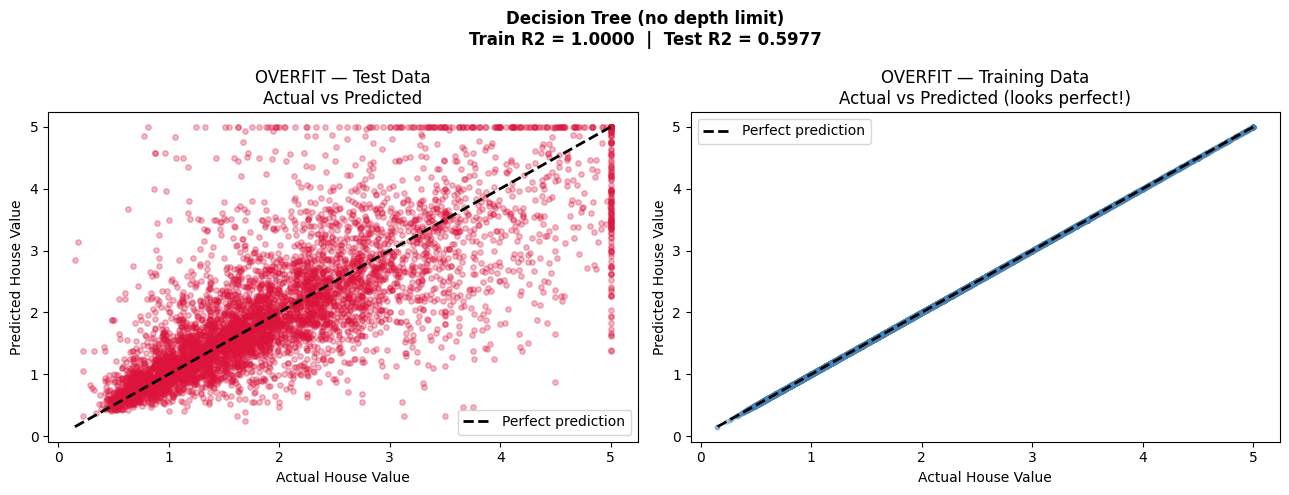

Left plot  (test data)  : dots are scattered far from the diagonal — bad predictions.

Right plot (train data) : dots sit exactly on the line — the model memorised every row.

This gap between training and test performance is the signature of overfitting.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Actual vs Predicted on TEST data ---
ax = axes[0]
ax.scatter(y_test, test_pred_of, color='crimson', alpha=0.3, s=15)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual House Value')
ax.set_ylabel('Predicted House Value')
ax.set_title('OVERFIT — Test Data\nActual vs Predicted')
ax.legend()

# --- Plot 2: Actual vs Predicted on TRAIN data ---
ax2 = axes[1]
ax2.scatter(y_train, train_pred_of, color='steelblue', alpha=0.2, s=10)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual House Value')
ax2.set_ylabel('Predicted House Value')
ax2.set_title('OVERFIT — Training Data\nActual vs Predicted (looks perfect!)')
ax2.legend()

plt.suptitle(
    f'Decision Tree (no depth limit)\nTrain R2 = {train_r2_of:.4f}  |  Test R2 = {test_r2_of:.4f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Left plot  (test data)  : dots are scattered far from the diagonal — bad predictions.')
print('Right plot (train data) : dots sit exactly on the line — the model memorised every row.')
print('This gap between training and test performance is the signature of overfitting.')

## Step 4 — Understand WHY It Overfit

The depth of a decision tree controls how complex it is.

- **Shallow tree (small depth)** — makes few splits, learns only the big patterns — may underfit
- **Deep tree (large depth)** — makes many splits, memorises every detail — overfits
- **Right depth** — enough splits to capture the real pattern without memorising noise

We will sweep depth from 1 to 20 and watch how training and test error change.

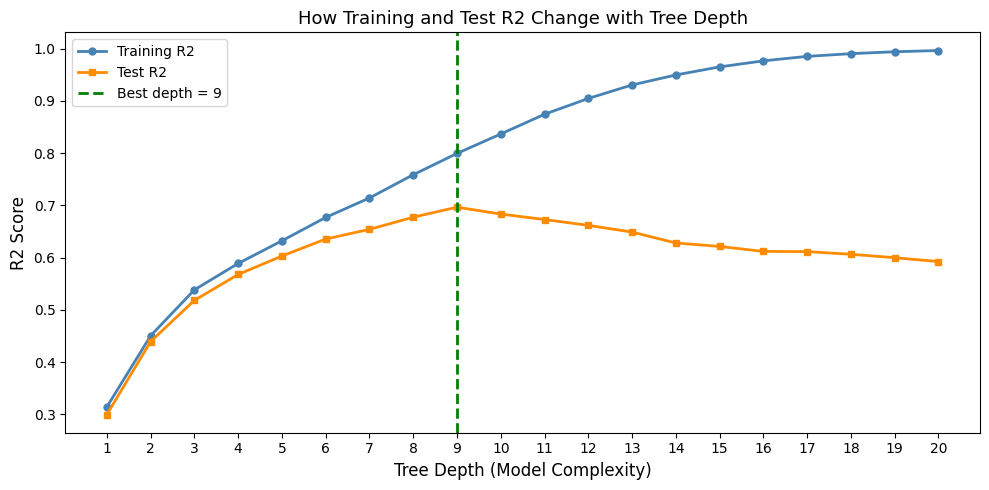

Best depth : 9  ->  Test R2 = 0.6965

Observations:

- Training R2 rises steadily and reaches 1.0 at high depth (memorised everything).

- Test R2 rises at first, then flattens or drops — overfitting begins.

- The best test performance is at depth 9.

In [ ]:
depths       = list(range(1, 21))
train_r2s    = []
test_r2s     = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_r2s.append(r2_score(y_train, m.predict(X_train)))
    test_r2s.append( r2_score(y_test,  m.predict(X_test)))

best_depth = depths[np.argmax(test_r2s)]
best_r2    = max(test_r2s)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(depths, train_r2s, 'o-', color='steelblue',  linewidth=2, markersize=5, label='Training R2')
plt.plot(depths, test_r2s,  's-', color='darkorange', linewidth=2, markersize=5, label='Test R2')
plt.axvline(best_depth, color='green', linestyle='--', linewidth=2,
            label=f'Best depth = {best_depth}')
plt.xlabel('Tree Depth (Model Complexity)', fontsize=12)
plt.ylabel('R2 Score', fontsize=12)
plt.title('How Training and Test R2 Change with Tree Depth', fontsize=13)
plt.xticks(depths)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best depth : {best_depth}  ->  Test R2 = {best_r2:.4f}')
print()
print('Observations:')
print('  - Training R2 rises steadily and reaches 1.0 at high depth (memorised everything).')
print('  - Test R2 rises at first, then flattens or drops — overfitting begins.')
print(f'  - The best test performance is at depth {best_depth}.')

## Step 5 — Fix Overfitting

We will fix overfitting using two methods:

**Fix 1 — Limit the tree depth.**  
Use the best depth we found above. This stops the tree from splitting too deep and memorising noise.

**Fix 2 — Ridge Regularisation on a Polynomial model.**  
Ridge adds a penalty for large weights, forcing the model to stay simple and smooth.
The `alpha` parameter controls how strong the penalty is — higher alpha means stronger restraint.

In [ ]:
# Fix 1 — Decision Tree with limited depth
model_fix1 = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
model_fix1.fit(X_train, y_train)

train_r2_f1  = r2_score(y_train, model_fix1.predict(X_train))
test_r2_f1   = r2_score(y_test,  model_fix1.predict(X_test))
train_mse_f1 = mean_squared_error(y_train, model_fix1.predict(X_train))
test_mse_f1  = mean_squared_error(y_test,  model_fix1.predict(X_test))

print(f'FIX 1 — Decision Tree with max_depth = {best_depth}')
print('-' * 50)
print(f'  Training  R2  : {train_r2_f1:.4f}')
print(f'  Test      R2  : {test_r2_f1:.4f}')
print(f'  Training  MSE : {train_mse_f1:.4f}')
print(f'  Test      MSE : {test_mse_f1:.4f}')
print(f'  Gap (Test - Train R2) : {test_r2_f1 - train_r2_f1:.4f}  <- much smaller now')
print()
print(f'Test R2 improved from {test_r2_of:.4f} to {test_r2_f1:.4f}')
print('The gap between training and test performance has closed significantly.')

FIX 1 — Decision Tree with max_depth = 9

--------------------------------------------------

Training  R2  : 0.7995

Test      R2  : 0.6965

Training  MSE : 0.2687

Test      MSE : 0.3983

Gap (Test - Train R2) : -0.1029  <- much smaller now

Test R2 improved from 0.5977 to 0.6965

The gap between training and test performance has closed significantly.

In [ ]:
# Fix 2 — Ridge Regularisation on a Polynomial model
# We try several alpha values and pick the best one
alphas = [0.01, 0.1, 1, 10, 100]

print('Fix 2 — Ridge Regularisation (Polynomial degree 2)')
print('-' * 55)
print(f'{"Alpha":>8}  {"Train R2":>10}  {"Test R2":>10}  {"Gap":>10}')
print('-' * 45)

best_alpha   = None
best_test_r2 = -999

for alpha in alphas:
    m = Pipeline([
        ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  Ridge(alpha=alpha))
    ])
    m.fit(X_train, y_train)
    tr = r2_score(y_train, m.predict(X_train))
    te = r2_score(y_test,  m.predict(X_test))
    print(f'{alpha:>8}  {tr:>10.4f}  {te:>10.4f}  {te - tr:>10.4f}')
    if te > best_test_r2:
        best_test_r2 = te
        best_alpha   = alpha

# Train the best Ridge model
model_fix2 = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=best_alpha))
])
model_fix2.fit(X_train, y_train)

train_r2_f2  = r2_score(y_train, model_fix2.predict(X_train))
test_r2_f2   = r2_score(y_test,  model_fix2.predict(X_test))
train_mse_f2 = mean_squared_error(y_train, model_fix2.predict(X_train))
test_mse_f2  = mean_squared_error(y_test,  model_fix2.predict(X_test))

print()
print(f'Best alpha = {best_alpha}  ->  Test R2 = {test_r2_f2:.4f}')

Fix 2 — Ridge Regularisation (Polynomial degree 2)

-------------------------------------------------------

Alpha    Train R2     Test R2         Gap

---------------------------------------------

0.01      0.6831      0.6720     -0.0111

0.1      0.6783      0.6700     -0.0083

1      0.6673      0.6528     -0.0145

10      0.6546      0.6348     -0.0198

100      0.6388      0.6284     -0.0105

Best alpha = 0.01  ->  Test R2 = 0.6720

## Step 6 — Compare All Three Models

Now we place all three models side by side — the overfit version and both fixes.

In [ ]:
print(f'{"Model":<45} {"Train R2":>10} {"Test R2":>10} {"Train MSE":>12} {"Test MSE":>12}')
print('-' * 95)

rows = [
    ('Overfit  (Decision Tree, no depth limit)',  train_r2_of,  test_r2_of,  train_mse_of,  test_mse_of),
    (f'Fix 1    (Decision Tree, depth={best_depth})',         train_r2_f1,  test_r2_f1,  train_mse_f1,  test_mse_f1),
    (f'Fix 2    (Ridge alpha={best_alpha}, poly degree 2)',   train_r2_f2,  test_r2_f2,  train_mse_f2,  test_mse_f2),
]

for name, tr2, te2, tmse, temse in rows:
    print(f'{name:<45} {tr2:>10.4f} {te2:>10.4f} {tmse:>12.4f} {temse:>12.4f}')

Model                                           Train R2    Test R2    Train MSE     Test MSE

-----------------------------------------------------------------------------------------------

Overfit  (Decision Tree, no depth limit)          1.0000     0.5977       0.0000       0.5280

Fix 1    (Decision Tree, depth=9)                 0.7995     0.6965       0.2687       0.3983

Fix 2    (Ridge alpha=0.01, poly degree 2)        0.6831     0.6720       0.4245       0.4305

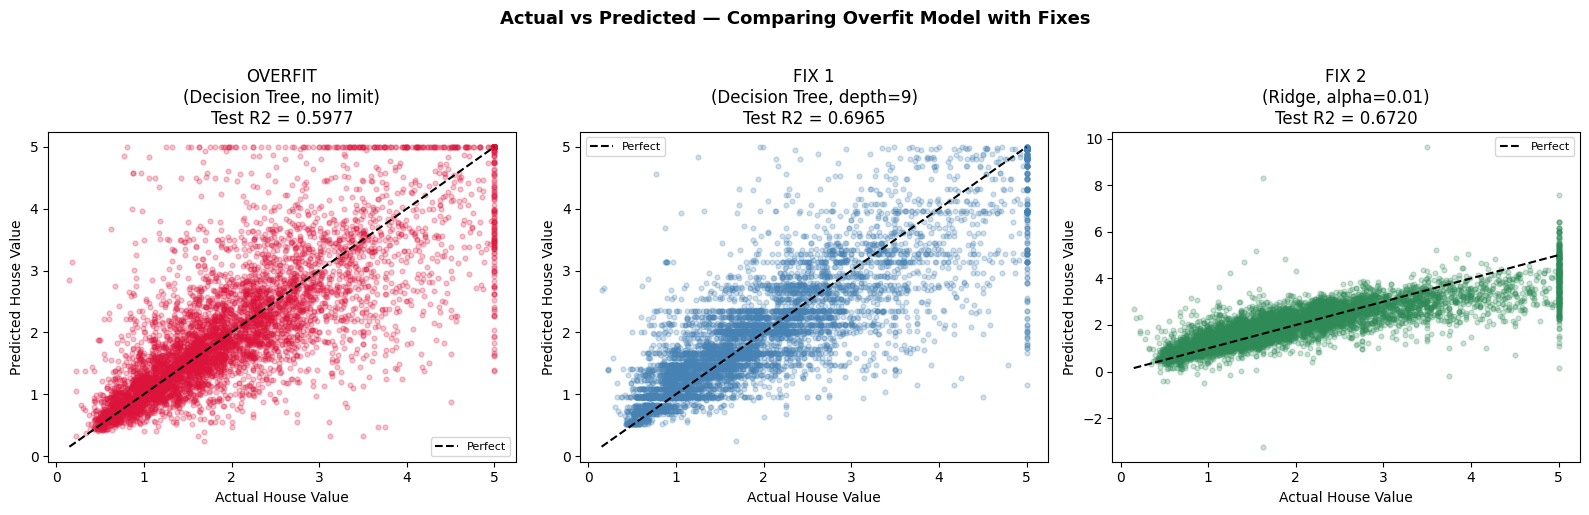

The closer the dots are to the diagonal dashed line, the better the model.

Overfit : Test R2 = 0.5977  — scattered, unreliable predictions

Fix 1   : Test R2 = 0.6965  — noticeably tighter

Fix 2   : Test R2 = 0.6720  — good alignment along the diagonal

In [ ]:
# Actual vs Predicted plots for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    (test_pred_of,                   test_r2_of,  'OVERFIT\n(Decision Tree, no limit)',         'crimson'),
    (model_fix1.predict(X_test),     test_r2_f1,  f'FIX 1\n(Decision Tree, depth={best_depth})', 'steelblue'),
    (model_fix2.predict(X_test),     test_r2_f2,  f'FIX 2\n(Ridge, alpha={best_alpha})',          'seagreen'),
]

for ax, (y_pred, r2, title, color) in zip(axes, configs):
    ax.scatter(y_test, y_pred, color=color, alpha=0.25, s=12)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual House Value')
    ax.set_ylabel('Predicted House Value')
    ax.set_title(f'{title}\nTest R2 = {r2:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Comparing Overfit Model with Fixes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('The closer the dots are to the diagonal dashed line, the better the model.')
print(f'Overfit : Test R2 = {test_r2_of:.4f}  — scattered, unreliable predictions')
print(f'Fix 1   : Test R2 = {test_r2_f1:.4f}  — noticeably tighter')
print(f'Fix 2   : Test R2 = {test_r2_f2:.4f}  — good alignment along the diagonal')

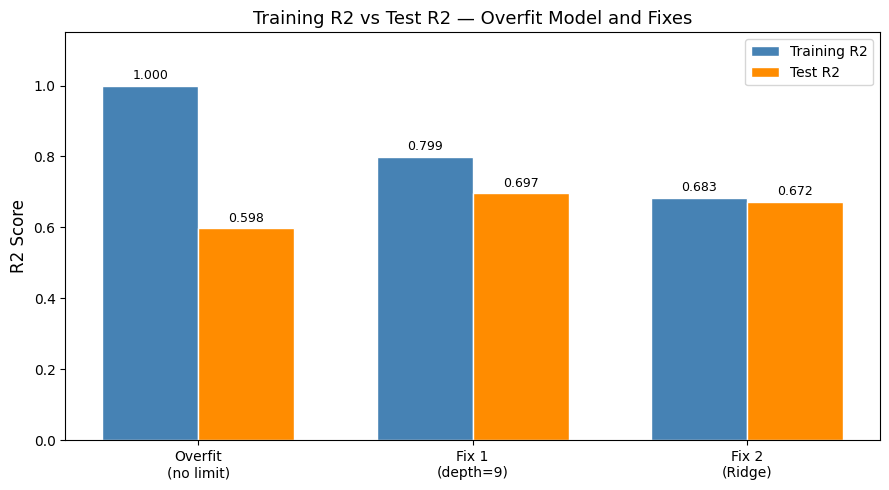

For the overfit model: Training R2 = 1.0 but Test R2 is much lower.

The large gap between the two bars is the hallmark of overfitting.

After fixing: Training R2 and Test R2 are much closer together.

In [ ]:
# Bar chart: Train R2 vs Test R2 for all three models
model_labels = ['Overfit\n(no limit)', f'Fix 1\n(depth={best_depth})', f'Fix 2\n(Ridge)']
train_r2_vals = [train_r2_of, train_r2_f1, train_r2_f2]
test_r2_vals  = [test_r2_of,  test_r2_f1,  test_r2_f2]

x      = np.arange(len(model_labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, train_r2_vals, width, label='Training R2', color='steelblue',  edgecolor='white')
bars2 = ax.bar(x + width/2, test_r2_vals,  width, label='Test R2',     color='darkorange', edgecolor='white')

# Label each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('R2 Score', fontsize=12)
ax.set_title('Training R2 vs Test R2 — Overfit Model and Fixes', fontsize=13)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('For the overfit model: Training R2 = 1.0 but Test R2 is much lower.')
print('The large gap between the two bars is the hallmark of overfitting.')
print('After fixing: Training R2 and Test R2 are much closer together.')

### The Gap Is the Signal

The single most important diagnostic for overfitting is the **gap between training and test performance**.

We visualise this gap directly below.

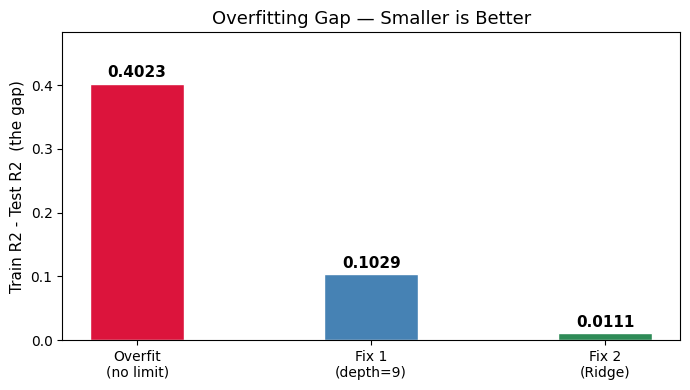

A large gap = model memorised training data = overfitting.

A small gap = model generalises well = what we want.

In [ ]:
gaps   = [train_r2_of - test_r2_of,
          train_r2_f1 - test_r2_f1,
          train_r2_f2 - test_r2_f2]
labels = ['Overfit\n(no limit)', f'Fix 1\n(depth={best_depth})', f'Fix 2\n(Ridge)']
colors = ['crimson', 'steelblue', 'seagreen']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, gaps, color=colors, edgecolor='white', width=0.4)

for bar, val in zip(bars, gaps):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Train R2 - Test R2  (the gap)', fontsize=11)
plt.title('Overfitting Gap — Smaller is Better', fontsize=13)
plt.ylim(0, max(gaps) * 1.2)
plt.tight_layout()
plt.show()

print('A large gap = model memorised training data = overfitting.')
print('A small gap = model generalises well = what we want.')

## Summary

### What we did

| Step | Model | Issue | Test R2 |
|------|-------|-------|---------|
| Overfit | Decision Tree, no depth limit | Memorised all training data | Low |
| Fix 1 | Decision Tree, limited depth | Stopped tree from going too deep | Better |
| Fix 2 | Ridge + Polynomial features | Penalised large weights | Best |

---

### How to recognise Overfitting

| Signal | What it means |
|--------|---------------|
| Training R2 is very high (near 1.0) | Model memorised training data |
| Test R2 is much lower | Model fails on new data |
| Large gap between train and test | Clear sign of overfitting |
| Actual vs Predicted is scattered | Predictions are unreliable |

---

### How to fix Overfitting

1. **Limit model complexity** — reduce tree depth, fewer polynomial degrees, fewer layers.
2. **Regularisation (Ridge / Lasso)** — penalise large weights to keep the model simple.
3. **Get more training data** — more data makes it harder to memorise and easier to generalise.
4. **Remove noisy or irrelevant features** — less noise means less to memorise.

---

### The key rule

> Overfitting means the model has learned too much — including the noise.
> The solution is always to constrain the model so it learns the pattern, not the noise.